In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

ROUND_NUMBER = 5
ROUND_FOLDER = Path(".")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")

# ── Load prices ───────────────────────────────────────────────────────────────
PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue
    day = int(match.group(1))
    DAY_LABELS.append(day)
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# ── Load trades ───────────────────────────────────────────────────────────────
TRADE_FILES = sorted(ROUND_FOLDER.glob(f"trades_round_{ROUND_NUMBER}_day_*.csv"))
trade_frames = []
for file_path in TRADE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue
    day = int(match.group(1))
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    trade_frames.append(df[["day", "timestamp", "symbol", "quantity"]])

vol = pd.DataFrame(columns=["day", "timestamp", "product", "quantity"])
if trade_frames:
    trades_raw = pd.concat(trade_frames, ignore_index=True).dropna(subset=["timestamp", "quantity"])
    trades_raw["timestamp"] = trades_raw["timestamp"].astype(float)
    vol = (
        trades_raw
        .groupby(["day", "timestamp", "symbol"], as_index=False)["quantity"]
        .sum()
        .rename(columns={"symbol": "product"})
    )

# ── Continuous x-axis offsets ─────────────────────────────────────────────────
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_ts = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_ts + gap / 2)
    current_offset += max_ts + gap

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}
BAR_WIDTH = 1200.0

# ── Draw function ─────────────────────────────────────────────────────────────
def draw_price_chart(show_volume):
    fig, axes = plt.subplots(
        len(products), 1,
        figsize=(16, max(4, 4 * len(products))),
        sharex=True,
    )
    if len(products) == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])
        product_vol = vol[vol["product"] == product] if show_volume else None
        ax2 = ax.twinx() if show_volume else None

        for day in DAY_LABELS:
            day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
            if day_prices.empty:
                continue

            x_values = day_prices["timestamp"] + x_offsets[day]
            ax.plot(x_values, day_prices["mid_price"],
                    color=color_map[day], linewidth=1.6, label=f"Day {day}")

            if show_volume and product_vol is not None and ax2 is not None:
                day_vol = product_vol[product_vol["day"] == day].sort_values("timestamp")
                if not day_vol.empty:
                    xv = day_vol["timestamp"] + x_offsets[day]
                    ax2.bar(xv, day_vol["quantity"], width=BAR_WIDTH,
                            color=color_map[day], alpha=0.25)

        for sep in separator_positions[:-1]:
            ax.axvline(sep, color="black", linewidth=2)

        ax.set_title(product.replace("_", " "))
        ax.set_ylabel("mid_price")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

        if show_volume and ax2 is not None:
            ax2.set_ylabel("volume", color="grey", fontsize=9)
            ax2.tick_params(axis="y", labelcolor="grey")
            ax2.set_ylim(bottom=0)

    axes[-1].set_xlabel("timestamp, concatenated across days")
    fig.suptitle(f"Price movements — {ROUND_FOLDER.name}", y=0.995)
    fig.tight_layout()
    plt.show()

# ── Widget ────────────────────────────────────────────────────────────────────
toggle = widgets.ToggleButton(
    value=False,
    description="Show Volume",
    button_style="info",
    icon="bar-chart",
    layout=widgets.Layout(width="150px"),
)
out = widgets.Output()

def _on_toggle(change):
    with out:
        out.clear_output(wait=True)
        draw_price_chart(show_volume=change["new"])

toggle.observe(_on_toggle, names="value")

with out:
    draw_price_chart(show_volume=False)

display(toggle, out)


ToggleButton(value=False, button_style='info', description='Show Volume', icon='bar-chart', layout=Layout(widt…

Output()

Detected categories: ['GALAXY_SOUNDS', 'MICROCHIP', 'OXYGEN_SHAKE', 'PANEL', 'PEBBLES', 'ROBOT', 'SLEEP_POD', 'SNACKPACK', 'TRANSLATOR', 'UV_VISOR']


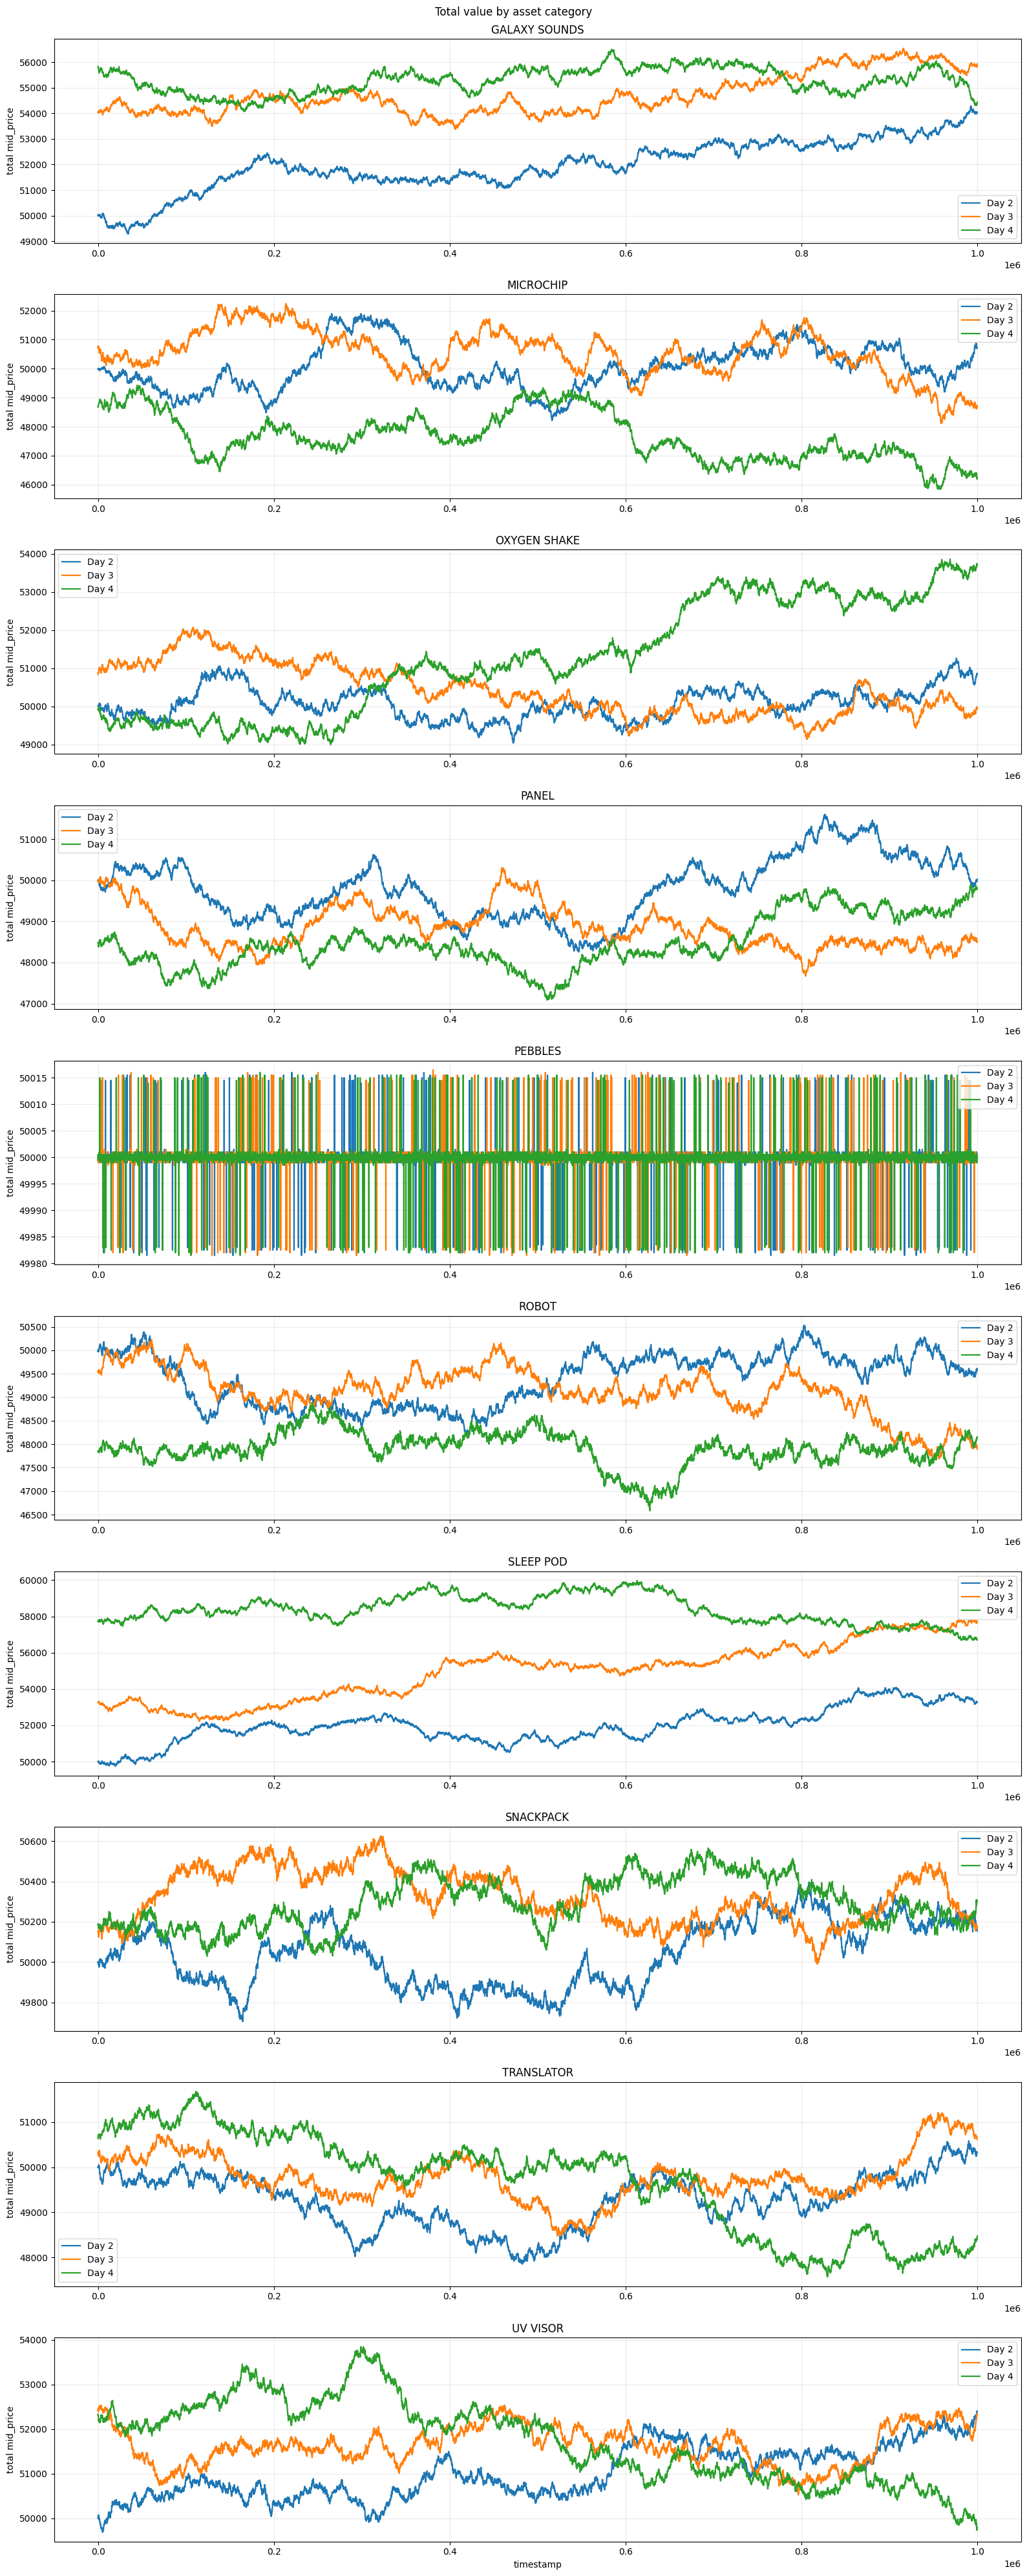

In [7]:

from collections import defaultdict

products = sorted(plot_prices["product"].dropna().unique())

# Determine category prefix per product.
# If all products sharing the same first token also share the same second token,
# use "FIRST_SECOND" as the category (e.g. GALAXY_SOUNDS, UV_VISOR); otherwise use "FIRST".
first_token_groups = defaultdict(list)
for p in products:
    first_token_groups[p.split("_")[0]].append(p)

product_category = {}
for first_token, group in first_token_groups.items():
    second_tokens = {p.split("_")[1] for p in group if len(p.split("_")) > 1}
    prefix = f"{first_token}_{second_tokens.pop()}" if len(second_tokens) == 1 else first_token
    for p in group:
        product_category[p] = prefix

categories = sorted(set(product_category.values()))
print("Detected categories:", categories)

# Sum mid_prices across all products in each category per (day, timestamp).
cat_prices = plot_prices.copy()
cat_prices["category"] = cat_prices["product"].map(product_category)
cat_totals = (
    cat_prices.groupby(["day", "timestamp", "category"])["mid_price"]
    .sum()
    .reset_index()
    .sort_values(["category", "day", "timestamp"])
)

# Plot â€” one subplot per category, each day as a separate coloured line.
fig, axes = plt.subplots(len(categories), 1, figsize=(16, max(4, 4 * len(categories))), sharex=False)
if len(categories) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, category in zip(axes, categories):
    cat_data = cat_totals[cat_totals["category"] == category]
    for day in DAY_LABELS:
        day_data = cat_data[cat_data["day"] == day].sort_values("timestamp")
        if day_data.empty:
            continue
        ax.plot(day_data["timestamp"], day_data["mid_price"], label=f"Day {day}",
                color=color_map[day], linewidth=1.6)
    ax.set_title(category.replace("_", " "))
    ax.set_ylabel("total mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp")
fig.suptitle("Total value by asset category", y=0.995)
fig.tight_layout()
plt.show()


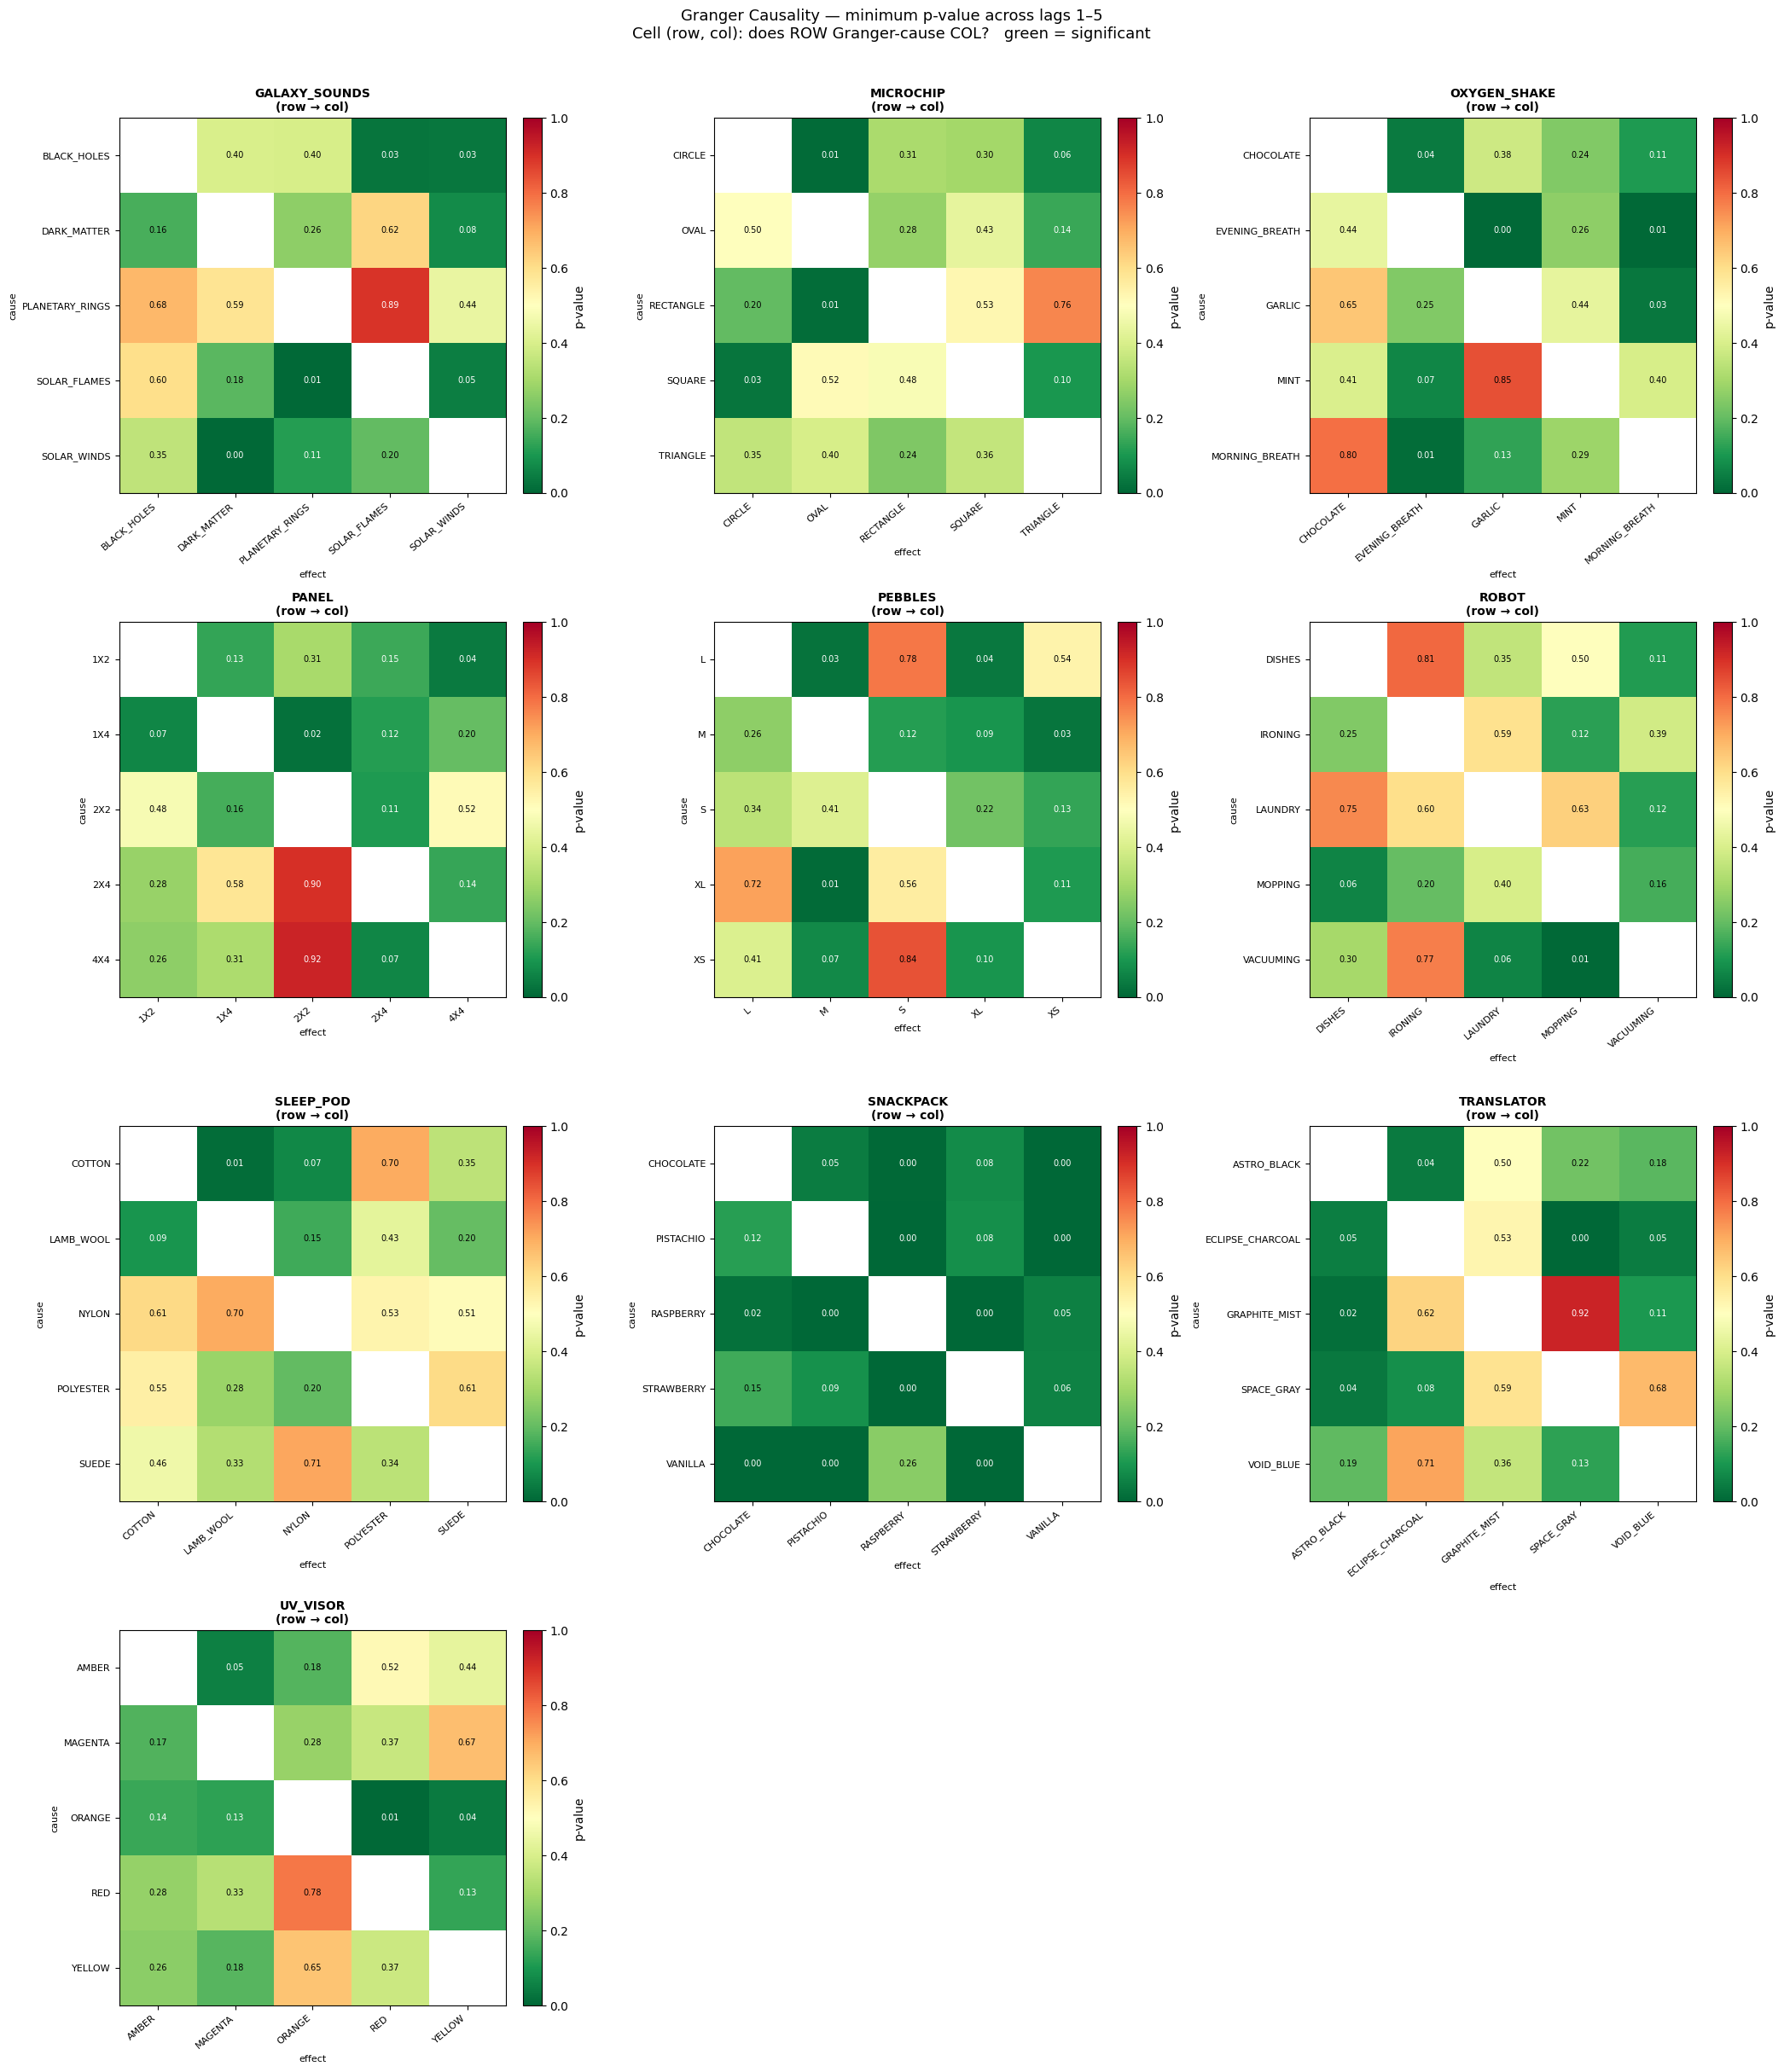


Significant Granger-causal pairs (p < 0.05): 41


,category,cause,effect,p_value
4,GALAXY_SOUNDS,SOLAR_WINDS,DARK_MATTER,0.0044
2,GALAXY_SOUNDS,SOLAR_FLAMES,PLANETARY_RINGS,0.0071
0,GALAXY_SOUNDS,BLACK_HOLES,SOLAR_FLAMES,0.0278
1,GALAXY_SOUNDS,BLACK_HOLES,SOLAR_WINDS,0.0338
3,GALAXY_SOUNDS,SOLAR_FLAMES,SOLAR_WINDS,0.0498
5,MICROCHIP,CIRCLE,OVAL,0.0090
6,MICROCHIP,RECTANGLE,OVAL,0.0127
7,MICROCHIP,SQUARE,CIRCLE,0.0293
9,OXYGEN_SHAKE,EVENING_BREATH,GARLIC,0.0049
10,OXYGEN_SHAKE,EVENING_BREATH,MORNING_BREATH,0.0052


In [2]:
import re
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# ── 0. Load price data ────────────────────────────────────────────────────────
ROUND_NUMBER = 5
ROUND_FOLDER = Path(".")
PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
DAY_RE = re.compile(r"day_(-?\d+)\.csv$")

DAY_LABELS_GC, frames = [], []
for fp in PRICE_FILES:
    m = DAY_RE.search(fp.name)
    if not m:
        continue
    day = int(m.group(1))
    DAY_LABELS_GC.append(day)
    df = pd.read_csv(fp, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

DAY_LABELS_GC = sorted(set(DAY_LABELS_GC))
_prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
_plot_prices = _prices.loc[_prices["mid_price"] > 0].copy()

MAX_LAG = 5

# ── 1. Wide pivot: one column per product, index = (day, timestamp) ──────────
pivot = (
    _plot_prices
    .sort_values(["day", "timestamp"])
    .pivot_table(index=["day", "timestamp"], columns="product", values="mid_price", aggfunc="mean")
)
pivot = pivot.ffill().bfill()

# First differences (returns) per day — reset at day boundaries
day_returns = []
for day in DAY_LABELS_GC:
    idx = pivot.index.get_level_values("day") == day
    day_slice = pivot.loc[idx]
    if not day_slice.empty:
        day_returns.append(day_slice.diff().iloc[1:])

returns = pd.concat(day_returns).reset_index(drop=True)

# ── 2. Build product → category map ──────────────────────────────────────────
all_products = sorted(returns.columns.tolist())
_first_groups = defaultdict(list)
for p in all_products:
    _first_groups[p.split("_")[0]].append(p)

product_category_gc = {}
for first_tok, group in _first_groups.items():
    second_toks = {p.split("_")[1] for p in group if len(p.split("_")) > 1}
    prefix = f"{first_tok}_{second_toks.pop()}" if len(second_toks) == 1 else first_tok
    for p in group:
        product_category_gc[p] = prefix

cat_products_gc = defaultdict(list)
for p, cat in product_category_gc.items():
    cat_products_gc[cat].append(p)

# ── 3. Pairwise Granger causality ─────────────────────────────────────────────
def granger_pval_matrix(df, max_lag=MAX_LAG):
    """Min p-value (F-test) across lags 1..max_lag. Row Granger-causes col."""
    cols = df.columns.tolist()
    pmat = pd.DataFrame(np.nan, index=cols, columns=cols)
    for cause in cols:
        for effect in cols:
            if cause == effect:
                continue
            data = df[[effect, cause]].dropna()
            if len(data) < max_lag * 3:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
                pmat.loc[cause, effect] = min(
                    res[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)
                )
            except Exception:
                pass
    return pmat

# ── 4. Plot one heatmap per category ─────────────────────────────────────────
sorted_cats = sorted(cat_products_gc.keys())
ncols = 3
nrows = (len(sorted_cats) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes_flat = np.array(axes).flatten()

for ax, category in zip(axes_flat, sorted_cats):
    prods = sorted(cat_products_gc[category])
    cat_ret = returns[prods].dropna()
    pmat = granger_pval_matrix(cat_ret)

    strip = category + "_"
    labels = [p[len(strip):] if p.startswith(strip) else p for p in prods]
    pmat.index = labels
    pmat.columns = labels

    vals = pmat.values.astype(float)
    im = ax.imshow(vals, vmin=0, vmax=1, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{category}\n(row → col)", fontsize=10, fontweight="bold")
    ax.set_xlabel("effect", fontsize=8)
    ax.set_ylabel("cause", fontsize=8)

    for i in range(len(labels)):
        for j in range(len(labels)):
            v = vals[i, j]
            if not np.isnan(v):
                txt_color = "white" if (v < 0.15 or v > 0.85) else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="p-value")

for ax in axes_flat[len(sorted_cats):]:
    ax.set_visible(False)

fig.suptitle(
    f"Granger Causality — minimum p-value across lags 1–{MAX_LAG}\n"
    "Cell (row, col): does ROW Granger-cause COL?   green = significant",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

# ── 5. Summary table of significant pairs (p < 0.05) ─────────────────────────
sig_rows = []
for category in sorted_cats:
    prods = sorted(cat_products_gc[category])
    cat_ret = returns[prods].dropna()
    pmat = granger_pval_matrix(cat_ret)
    strip = category + "_"
    labels = [p[len(strip):] if p.startswith(strip) else p for p in prods]
    pmat.index = labels
    pmat.columns = labels
    for cause in labels:
        for effect in labels:
            if cause == effect:
                continue
            v = pmat.loc[cause, effect]
            if not np.isnan(v) and v < 0.05:
                sig_rows.append({"category": category, "cause": cause, "effect": effect, "p_value": round(v, 4)})

sig_df = pd.DataFrame(sig_rows).sort_values(["category", "p_value"])
print(f"\nSignificant Granger-causal pairs (p < 0.05): {len(sig_df)}")
sig_df


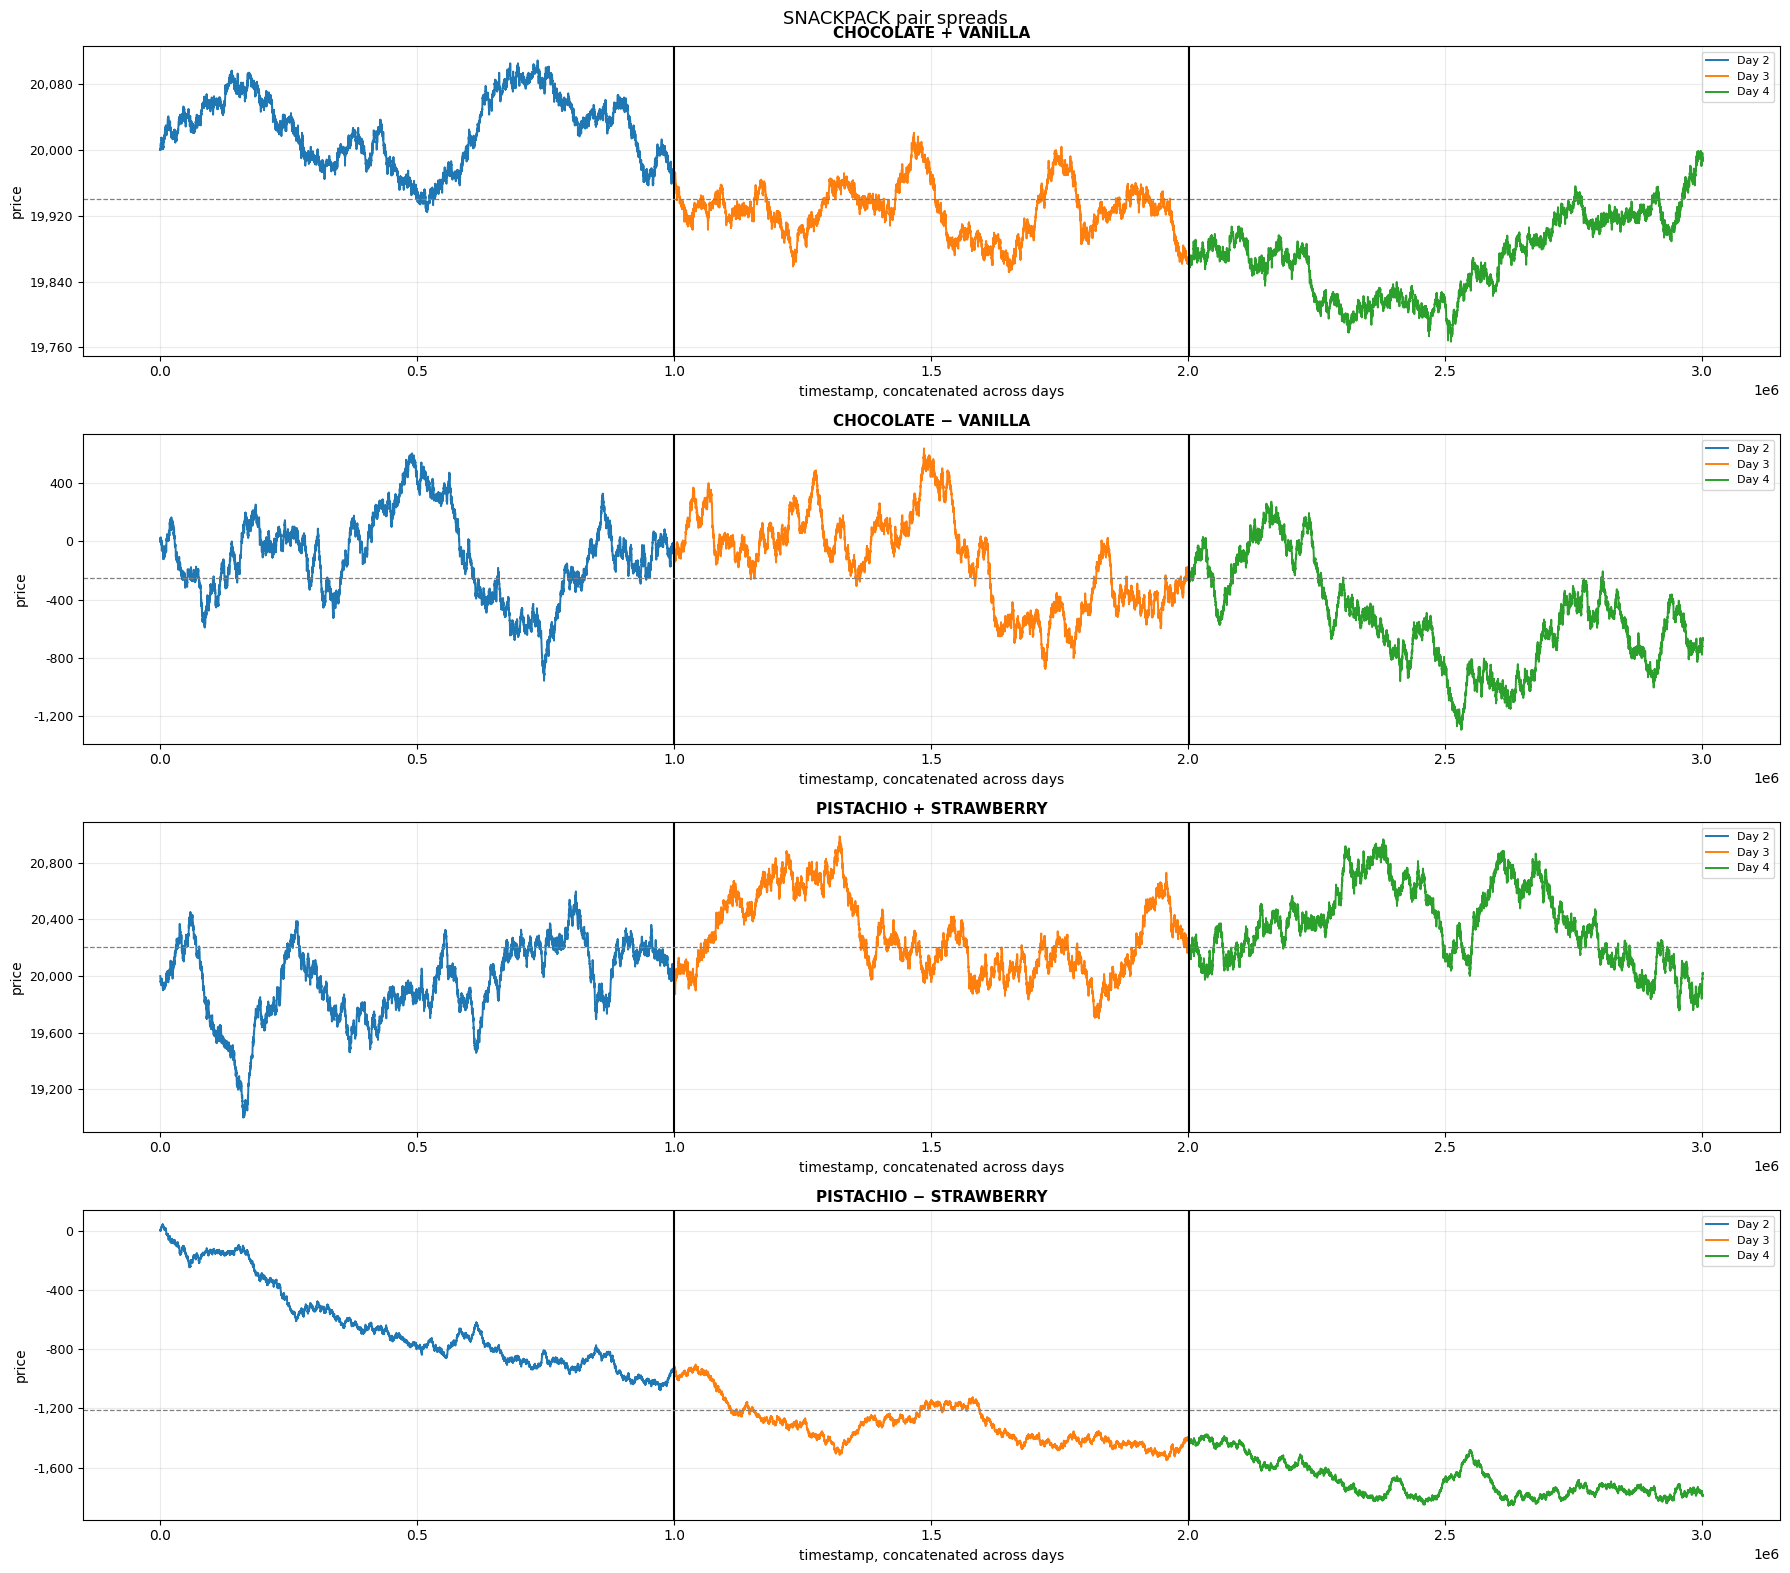

In [6]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Pairs to plot: (A, B) shows A+B then A-B stacked vertically
PAIRS = [
    ("SNACKPACK_CHOCOLATE", "SNACKPACK_VANILLA"),
    ("SNACKPACK_PISTACHIO", "SNACKPACK_STRAWBERRY"),
]

n_plots = len(PAIRS) * 2
fig, axes = plt.subplots(n_plots, 1, figsize=(18, 4 * n_plots))

for row, (a, b) in enumerate(PAIRS):
    prices_a = (
        plot_prices[plot_prices["product"] == a]
        .set_index(["day", "timestamp"])["mid_price"]
    )
    prices_b = (
        plot_prices[plot_prices["product"] == b]
        .set_index(["day", "timestamp"])["mid_price"]
    )

    combined = pd.DataFrame({"a": prices_a, "b": prices_b}).dropna()
    combined["sum"]  = combined["a"] + combined["b"]
    combined["diff"] = combined["a"] - combined["b"]

    short_a = a.replace("SNACKPACK_", "")
    short_b = b.replace("SNACKPACK_", "")

    for col, (series_key, label) in enumerate([("sum", f"{short_a} + {short_b}"),
                                               ("diff", f"{short_a} − {short_b}")]):
        ax = axes[row * 2 + col]

        for day in DAY_LABELS:
            day_mask = combined.index.get_level_values("day") == day
            day_data = combined.loc[day_mask]
            if day_data.empty:
                continue
            x = day_data.index.get_level_values("timestamp").astype(float) + x_offsets[day]
            ax.plot(x, day_data[series_key], color=color_map[day],
                    linewidth=1.4, label=f"Day {day}")

        for sep in separator_positions[:-1]:
            ax.axvline(sep, color="black", linewidth=1.5)

        ax.axhline(combined[series_key].mean(), color="grey", linewidth=0.9, linestyle="--")
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_ylabel("price")
        ax.set_xlabel("timestamp, concatenated across days")
        ax.grid(alpha=0.25)
        ax.legend(loc="best", fontsize=8)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(axis="y", labelsize=9)

fig.suptitle("SNACKPACK pair spreads", fontsize=13)
fig.tight_layout()
plt.show()
